In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [107]:
X,y = make_classification(n_features=2,n_samples=100,n_informative=1, hypercube=False,class_sep=3,
                         n_classes=2,n_redundant=0,n_clusters_per_class=1,random_state=42)

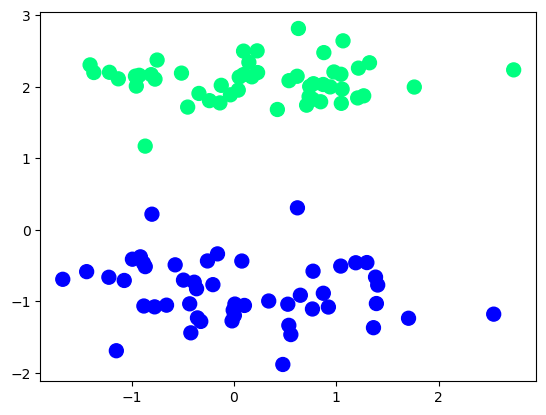

In [108]:
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.show()

In [19]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [111]:
lg = LogisticRegression(solver='saga',penalty='elasticnet',l1_ratio=0.5)

In [112]:
lg.fit(X_train,y_train)

,penalty,'elasticnet'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'saga'
,max_iter,100
,multi_class,'deprecated'


In [113]:
y_pred = lg.predict(X_test)

In [114]:
accuracy_score(y_test,y_pred)

0.6

In [115]:
lg.coef_

array([[0.04664624, 0.68215226]])

In [116]:
lg.intercept_

array([0.09041064])

In [117]:
m1 = -(lg.coef_[0][0]/lg.coef_[0][1])
b1 = -(lg.intercept_/lg.coef_[0][1])

In [118]:
x_input = np.linspace(-3,3,100)
y_input = m1*x_input + b1

In [119]:
class manual_lg:
    def __init__(self):
        pass

    def fit(self,X_train,y_train):
        X_train = np.insert(X_train,0,1,axis=1)
        W = np.ones(X_train.shape[1])
        lr = 0.1

        #print(X_train.shape,W.shape)
        
        for i in range(100):
            y_hat = sigmoid(np.dot(X_train,W))
           # W = W + lr * (1/X_train.shape[0]) * np.dot(np.dot(y_train,y_hat),(X_train))
            W = W + lr * (np.dot((y_train - y_hat),X_train)/X_train.shape[0])

        return W[0],W[1:]

In [120]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [121]:
mlg = manual_lg()

In [122]:
intercept_,coef_ = mlg.fit(X,y)

In [123]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [124]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input1 + b

(-2.0, 3.0)

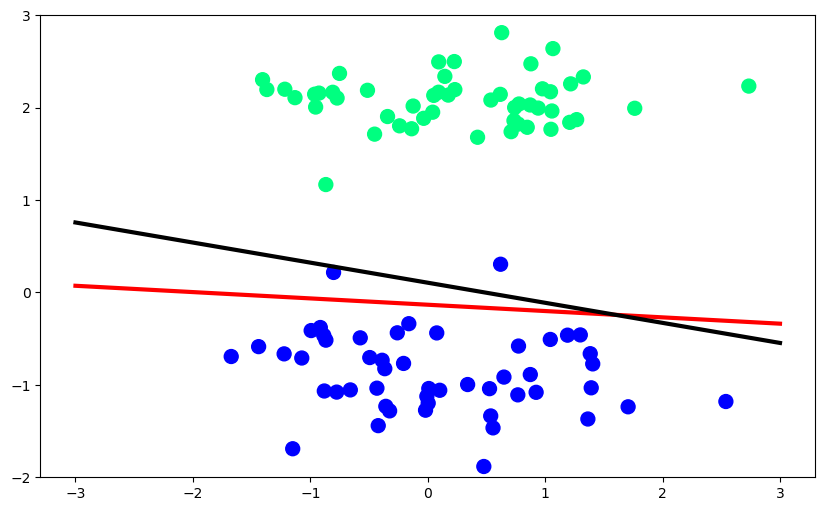

In [126]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-2,3)